In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
master = pd.read_csv("../data/cleaned/master_dataset.csv")

In [3]:
master["order_purchase_timestamp"] = pd.to_datetime(
    master["order_purchase_timestamp"]
)

In [4]:
master["PurchaseMonth"] = (
    master["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [5]:
cohort = master.groupby(
    "customer_unique_id"
)["PurchaseMonth"].min()

In [6]:
master["CohortMonth"] = master[
    "customer_unique_id"
].map(cohort)

In [7]:
master[
[
"customer_unique_id",
"PurchaseMonth",
"CohortMonth"
]
].head()

,customer_unique_id,PurchaseMonth,CohortMonth
0,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09
1,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09
2,7c396fd4830fd04220f754e42b4e5bff,2017-10,2017-09
3,af07308b275d755c9edb36a90c618231,2018-07,2018-07
4,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08


In [8]:
master["PurchaseYear"] = (
    master["order_purchase_timestamp"]
    .dt.year
)

master["PurchaseMonthNum"] = (
    master["order_purchase_timestamp"]
    .dt.month
)

In [9]:
master["CohortYear"] = (
    master["CohortMonth"]
    .dt.year
)

master["CohortMonthNum"] = (
    master["CohortMonth"]
    .dt.month
)

In [10]:
year_diff = (
    master["PurchaseYear"]
    -
    master["CohortYear"]
)

In [11]:
month_diff = (
    master["PurchaseMonthNum"]
    -
    master["CohortMonthNum"]
)

In [12]:
master["CohortIndex"] = (
    year_diff * 12
    +
    month_diff
    +
    1
)

In [13]:
master[
[
"customer_unique_id",
"CohortMonth",
"PurchaseMonth",
"CohortIndex"
]
].head(10)

,customer_unique_id,CohortMonth,PurchaseMonth,CohortIndex
0,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,2
1,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,2
2,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-10,2
3,af07308b275d755c9edb36a90c618231,2018-07,2018-07,1
4,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08,1
5,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11,1
6,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02,1
7,80bb27c7c16e8f973207a5086ab329e2,2017-07,2017-07,1
8,36edbb3fb164b1f16485364b6fb04c73,2017-04,2017-04,1
9,932afa1e708222e5821dac9cd5db4cae,2017-05,2017-05,1


In [14]:
cohort_data = master.groupby(
[
"CohortMonth",
"CohortIndex"
]
)["customer_unique_id"].nunique()

cohort_data = cohort_data.reset_index()

In [15]:
cohort_counts = cohort_data.pivot(
index="CohortMonth",
columns="CohortIndex",
values="customer_unique_id"
)

cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [16]:
cohort_counts.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [17]:
cohort_counts

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,NaN,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,4.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,5.0,NaN,NaN,NaN
2017-05,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0,9.0,11.0,9.0,12.0,9.0,1.0,7.0,9.0,NaN,NaN,NaN,NaN
2017-06,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0,4.0,7.0,10.0,11.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


In [18]:
cohort_sizes = cohort_counts.iloc[:,0]

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
)

In [19]:
retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.006231
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,NaN,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,NaN
2017-02,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,NaN,NaN


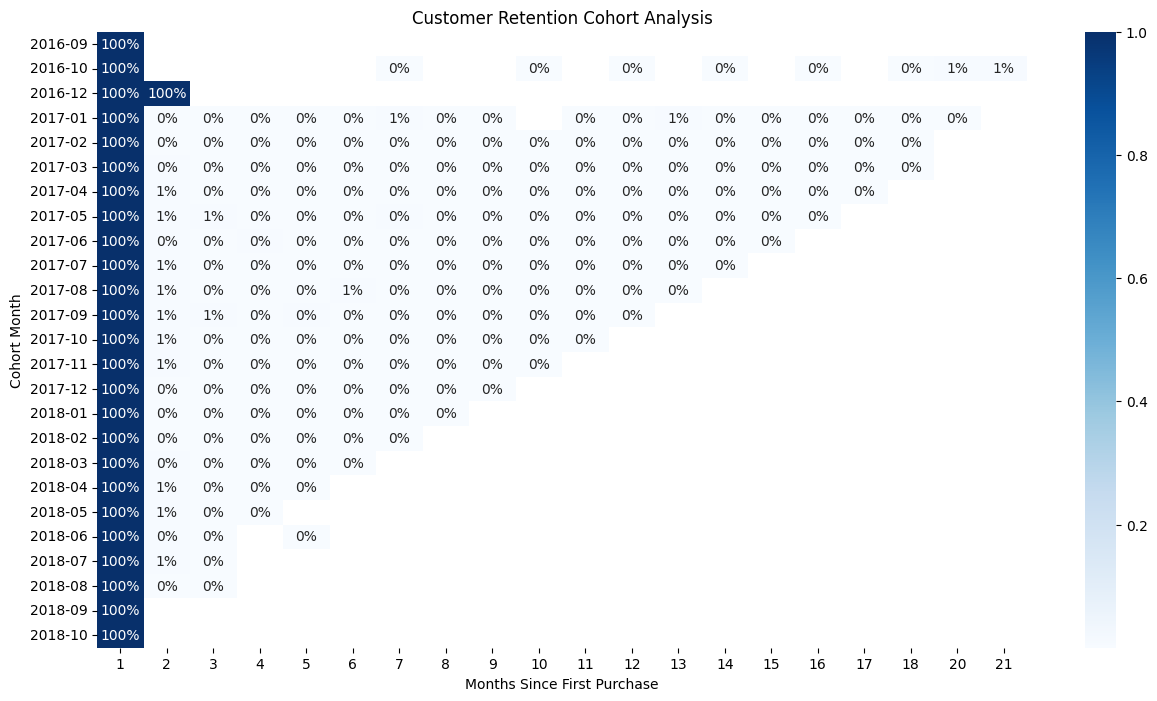

In [20]:
plt.figure(figsize=(15,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title(
    "Customer Retention Cohort Analysis"
)

plt.ylabel("Cohort Month")

plt.xlabel("Months Since First Purchase")

plt.show()

In [21]:
cohort_sizes = cohort_counts.iloc[:,0]

retention = cohort_counts.divide(
    cohort_sizes,
    axis=0
)

In [22]:
retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003115,NaN,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,NaN,0.003115,0.006231,0.006231
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.003927,0.002618,0.001309,0.003927,0.001309,0.005236,0.001309,0.001309,NaN,0.003927,0.001309,0.007853,0.003927,0.001309,0.001309,0.002618,0.003927,0.001309,NaN
2017-02,1.0,0.002283,0.002854,0.001142,0.003995,0.001142,0.002283,0.001712,0.001712,0.002283,0.001142,0.002854,0.001712,0.001712,0.001142,0.000571,0.000571,0.002283,NaN,NaN


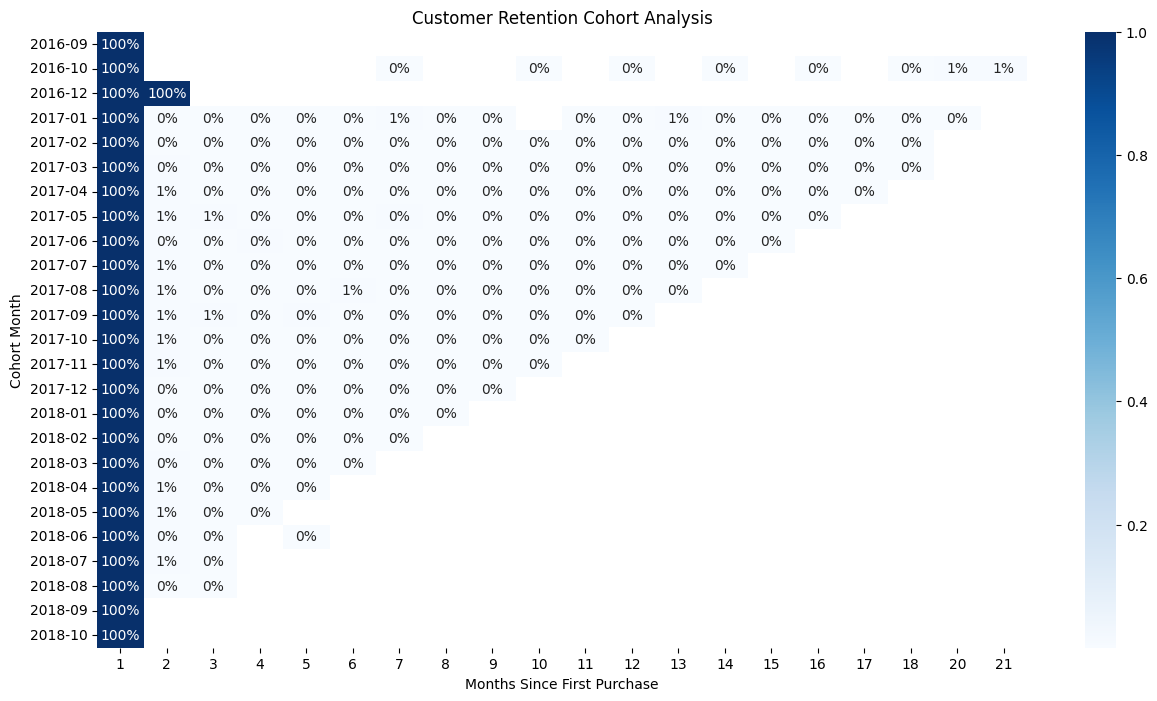

In [23]:
plt.figure(figsize=(15,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title(
    "Customer Retention Cohort Analysis"
)

plt.ylabel("Cohort Month")

plt.xlabel("Months Since First Purchase")

plt.show()